In [1]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import scipy
from scipy.stats import pearsonr
import sklearn
from sklearn import datasets, linear_model
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv(r'C:\0.MScProjectCode\MSc-Flower-NHSdataset\data\gbsg.csv', index_col='Unnamed: 0')
df.head()

,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
1,132,49,0,18,2,2,0,0,0,1838,0
2,1575,55,1,20,3,16,0,0,0,403,1
3,1140,56,1,40,3,3,0,0,0,1603,0
4,769,45,0,25,3,1,0,4,0,177,0
5,130,65,1,30,2,5,0,36,1,1855,0


In [3]:
df.head()

,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
1,132,49,0,18,2,2,0,0,0,1838,0
2,1575,55,1,20,3,16,0,0,0,403,1
3,1140,56,1,40,3,3,0,0,0,1603,0
4,769,45,0,25,3,1,0,4,0,177,0
5,130,65,1,30,2,5,0,36,1,1855,0


In [4]:
X = df.drop('status',axis=1)
y = df['status']

In [5]:
X.head()

,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime
1,132,49,0,18,2,2,0,0,0,1838
2,1575,55,1,20,3,16,0,0,0,403
3,1140,56,1,40,3,3,0,0,0,1603
4,769,45,0,25,3,1,0,4,0,177
5,130,65,1,30,2,5,0,36,1,1855


In [6]:
y.head()

1    0
2    1
3    0
4    0
5    0
Name: status, dtype: int64

<Axes: >

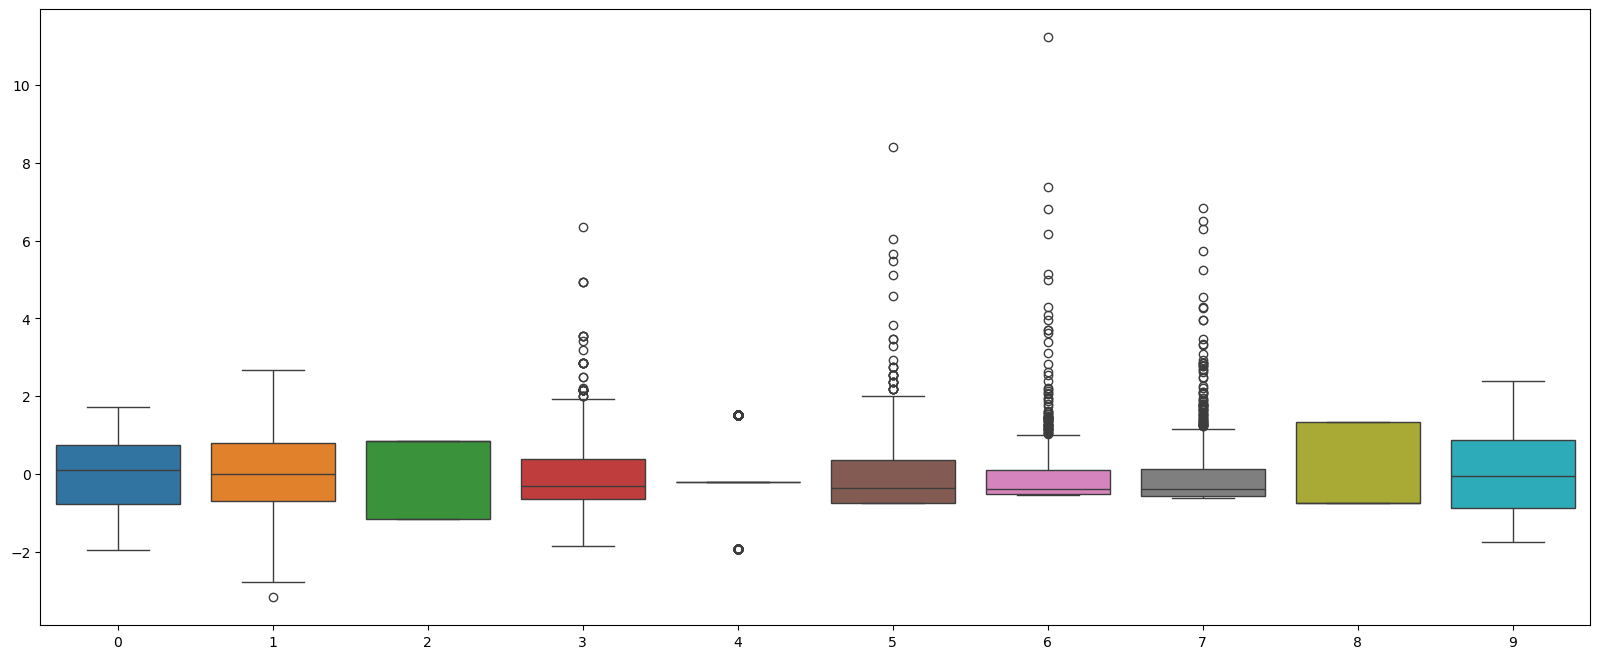

In [7]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
fig,ax=plt.subplots(1,figsize=(20,8))
sns.boxplot(data=Xs,ax=ax)

In [8]:
Xs_train, Xs_test, y_train, y_test = train_test_split(Xs, y, test_size=0.3, random_state=1, stratify=y)


In [9]:
log_reg = LogisticRegression()
log_reg.fit(Xs_train, y_train)
classifier_score = log_reg.score(Xs_test, y_test)
print('The classifier accuracy score is {:03.2f}'.format(classifier_score))

The classifier accuracy score is 0.82


# now trying ibm dp log reg

In [10]:
from diffprivlib.models import LogisticRegression

In [11]:
dp_log_reg = LogisticRegression(data_norm=12, epsilon=2, random_state=1234)
dp_log_reg.fit(Xs_train, y_train)
dp_classifier_score = dp_log_reg.score(Xs_test, y_test)
print('The classifier accuracy score is {:03.2f}'.format(dp_classifier_score))

The classifier accuracy score is 0.70


Text(0, 0.5, 'test accuracy')

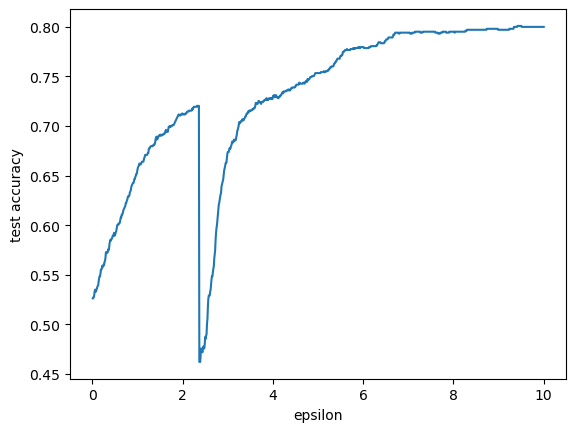

In [12]:
epsilon_list = np.arange(0.01,10.01,0.01)

clf_scores = []
for eps in epsilon_list:
    intra_round_scores = []
    for trial in range(5):
        dp_log_reg = LogisticRegression(data_norm=9, epsilon=eps, random_state=trial)
        dp_log_reg.fit(Xs_train, y_train)
        score = dp_log_reg.score(Xs_test, y_test)
        intra_round_scores.append(score)
    
    mean_intraroundscore = np.mean(intra_round_scores)
    clf_scores.append(mean_intraroundscore)

plt.plot(epsilon_list, clf_scores)
plt.xlabel('epsilon')
plt.ylabel('test accuracy')
    

Text(0, 0.5, 'test accuracy')

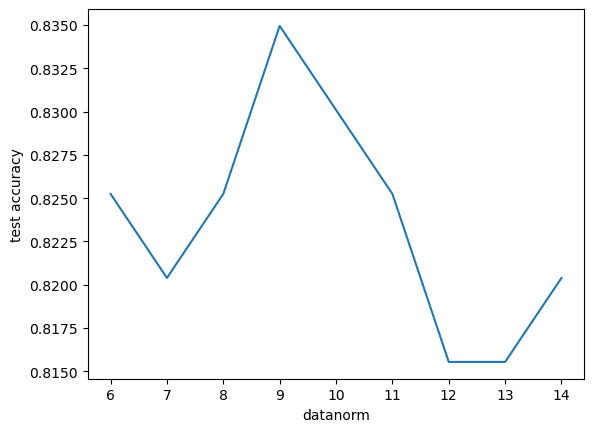

In [13]:
datanorm_list = np.arange(6,15)

clf_scores = []
for dn in datanorm_list:
    dp_log_reg = LogisticRegression(data_norm=dn, epsilon=10, random_state=1)
    dp_log_reg.fit(Xs_train, y_train)
    dp_classifier_score = dp_log_reg.score(Xs_test, y_test)
    clf_scores.append(dp_classifier_score)

plt.plot(datanorm_list, clf_scores)
plt.xlabel('datanorm')
plt.ylabel('test accuracy')

In [14]:
# Calculate the L2 norm of each sample in Xs_train
sample_norms = np.linalg.norm(Xs_train, axis=1)
# The data norm is the maximum L2 norm
data_norm = np.max(sample_norms)
print("Data norm:", data_norm)

Data norm: 13.092443263009141
